In [14]:
from costs.euler import EulerCost
import matplotlib.pyplot as plt
from equations.lotka_volterra import LotkaVolterraFullQuantum
from ansatz import ULA
import numpy as np
import qiskit as qk
import nevergrad as ng
from tqdm import tqdm
from omegaconf import DictConfig
from p_tqdm import p_map
from itertools import product
import scienceplots
plt.style.use("science")


In [2]:
# Make the ULA
ULA_config = {"ULA": {"n_qubits": 1, "depth": 1}}
ansatz, ansatz_params = ULA(1, 1)

In [3]:
lv = LotkaVolterraFullQuantum()

In [4]:
# Sample possible LV states
n_experiments = 100
state_list = list(np.random.rand(n_experiments, 2))
state_lambdas = []

# Find the ULA lambdas for each state
for state in tqdm(state_list):
    lambda_0 = np.linalg.norm(state)
    u0_normalized = state / lambda_0
    
    def _ic_cost(lambdas) -> float:   
        param_map = {ansatz_params[i]: lambdas[i] for i in range(len(lambdas))}
        circuit_ic = ansatz.assign_parameters(param_map, inplace=False)
        op = qk.quantum_info.Operator(circuit_ic)
        statevector = op.data[:, 0]
        cost = np.linalg.norm(statevector - u0_normalized) ** 2
        return cost
    
    optimizer = ng.optimizers.NGOpt(parametrization=len(ansatz_params), budget=1000)
    state_result = optimizer.minimize(_ic_cost)
    single_state_lambdas = [lambda_0] + list(state_result.value)
    state_lambdas.append(single_state_lambdas)
    

  0%|          | 0/100 [00:00<?, ?it/s]

100%|██████████| 100/100 [03:03<00:00,  1.84s/it]


In [5]:
# Exact cost values for each state
cost_params_exact = DictConfig({
        "tau": 0.1,
        "backend_type": "exact"
    })
euler_cost_exact = EulerCost(lv, cost_params_exact)
euler_cost_exact.compile_with_ansatz(ansatz, ansatz_params, ansatz_cfg=ULA_config)

In [6]:
exact_costs = []
for state, lambdas in zip(state_list, state_lambdas):
    cost = euler_cost_exact.compute_cost(lambdas, state_lambdas[0], 0.0, state_list[0])
    exact_costs.append(cost)

In [7]:
# Fake noisy machine
shot_options = [10**i for i in range(1, 8)]
shot_costs = {shots: [] for shots in shot_options}
shot_classes = []

for shots in shot_options:
    shot_config = DictConfig({
        "tau": 0.1,
        "backend_type": "fakeboston",
        "shots": shots
    })
    euler_shot = EulerCost(lv, shot_config)
    euler_shot.compile_with_ansatz(ansatz, ansatz_params, ansatz_cfg=ULA_config)
    shot_classes.append(euler_shot)

experiments = list(product(shot_classes, state_lambdas))
cost_maker = lambda exp: exp[0].compute_cost(exp[1], state_lambdas[0], 0.0, state_list[0])


In [8]:
costs_noisy_machine = p_map(cost_maker, experiments)

100%|██████████| 700/700 [15:09<00:00,  1.30s/it]


In [9]:
# Ideal machine
shot_classes = []

for shots in shot_options:
    shot_config = DictConfig({
        "tau": 0.1,
        "backend_type": "aer_simulator",
        "shots": shots
    })
    euler_shot = EulerCost(lv, shot_config)
    euler_shot.compile_with_ansatz(ansatz, ansatz_params, ansatz_cfg=ULA_config)
    shot_classes.append(euler_shot)
    
experiments = list(product(shot_classes, state_lambdas))
cost_maker = lambda exp: exp[0].compute_cost(exp[1], state_lambdas[0], 0.0, state_list[0])

In [10]:
costs_ideal_machine = p_map(cost_maker, experiments)

100%|██████████| 700/700 [01:45<00:00,  6.62it/s]


In [11]:
costs_noisy_arr = np.array(costs_noisy_machine).reshape(-1, n_experiments)
costs_ideal_arr = np.array(costs_ideal_machine).reshape(-1, n_experiments)
costs_exact_arr = np.array(exact_costs)

In [12]:
errs_noisy = np.abs((costs_noisy_arr - costs_exact_arr) / costs_exact_arr)
errs_ideal = np.abs((costs_ideal_arr - costs_exact_arr) / costs_exact_arr)


Text(0, 0.5, '$E_{\\mathrm{rel}}$')

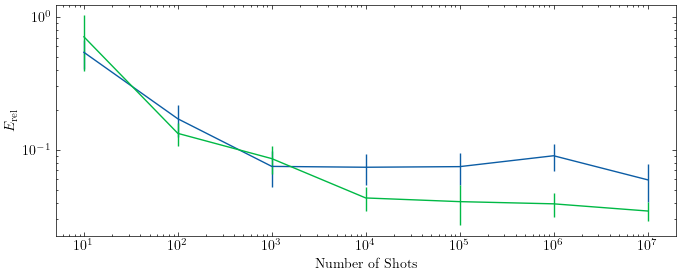

In [ ]:
plt.figure(figsize=(8, 3))
plt.errorbar(shot_options, errs_noisy.mean(axis = 1), errs_noisy.std(axis = 1) / np.sqrt(n_experiments), label="FakeBoston")
plt.errorbar(shot_options, errs_ideal.mean(axis = 1), errs_ideal.std(axis = 1) / np.sqrt(n_experiments), label="AERSimulator")
plt.xscale('log')
plt.yscale('log')
plt.xlabel("Number of Shots")
plt.ylabel(r"$E_{\mathrm{rel}}$")
plt.legend()

In [ ]:
exact_costs

[np.float64(-0.3162826645735279),
 np.float64(-0.08992089055610997),
 np.float64(-0.05270784575694665),
 np.float64(-0.2841207302453346),
 np.float64(-0.2930263307939447),
 np.float64(-0.2511611982308908),
 np.float64(-0.2507904042548506),
 np.float64(-0.06567730932765259),
 np.float64(-0.2660413120519445),
 np.float64(-0.30443672034585323),
 np.float64(-0.19833083168052454),
 np.float64(-0.06825709833886684),
 np.float64(0.08985472064951594),
 np.float64(-0.29338285510718753),
 np.float64(0.3825181540023239),
 np.float64(0.22017273635457668),
 np.float64(-0.15562881856905908),
 np.float64(0.07376366448700844),
 np.float64(-0.30125799235709627),
 np.float64(0.07752861285041934),
 np.float64(-0.14830129611397952),
 np.float64(-0.24680694726661345),
 np.float64(-0.2768956128982899),
 np.float64(-0.14470889921852473),
 np.float64(-0.2768066591008078),
 np.float64(-0.173000875151136),
 np.float64(-0.024838393164802297),
 np.float64(0.019918358724921204),
 np.float64(-0.17067725231163855),


In [ ]:
shot_costs[100000]

[np.float64(-0.3162926106542511),
 np.float64(-0.08365191040006292),
 np.float64(-0.05183754935782081),
 np.float64(-0.2839851965691479),
 np.float64(-0.2914051282966289),
 np.float64(-0.2542445407934958),
 np.float64(-0.2507767038086232),
 np.float64(-0.06800086303547648),
 np.float64(-0.26507709132964297),
 np.float64(-0.30457355228820193),
 np.float64(-0.19823181251674446),
 np.float64(-0.060526097963321424),
 np.float64(0.08418857297598592),
 np.float64(-0.29241887850199355),
 np.float64(0.37963763669548145),
 np.float64(0.2216378432720305),
 np.float64(-0.16192921129715876),
 np.float64(0.06535185039801333),
 np.float64(-0.30136334709407986),
 np.float64(0.07871799668532253),
 np.float64(-0.14666670715799573),
 np.float64(-0.24647329404370888),
 np.float64(-0.27940973368841526),
 np.float64(-0.1437405384839079),
 np.float64(-0.2764776643577267),
 np.float64(-0.17394790314572003),
 np.float64(-0.011868340370551622),
 np.float64(0.01827562946990624),
 np.float64(-0.16646284647670662